# Entrega 3 — Chunking de Manifestações Longas
As 5 manifestações mais longas (> 500 caracteres) perdem contexto quando indexadas como um bloco único. Aqui dividimos cada uma com o `RecursiveCharacterTextSplitter` do LangChain e comparamos configurações de `(chunk_size, chunk_overlap)`.

In [1]:
import json
import os
import warnings
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")  # evita aviso do joblib no Windows
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

with open("data/manifestacoes.json", encoding="utf-8") as f:
    manifestacoes = json.load(f)
df = pd.DataFrame(manifestacoes)
idx = {m: i for i, m in enumerate(df["id"])}
print(df.shape)
df.head()

(40, 4)


,id,data,categoria_oficial,texto
0,M001,2026-03-02,infraestrutura,"Calçada toda quebrada na Rua das Flores, perto do número 120. Dois idosos já caíram tentando passar por ali e ningué..."
1,M002,2026-03-02,saúde,Fiquei mais de cinco horas esperando atendimento na UPA do Centro com meu filho de dois anos com febre alta. Só havi...
2,M003,2026-03-03,infraestrutura,"Tem um buraco enorme na Av. Brasil, em frente ao supermercado Bom Preço. Vários carros já estouraram o pneu e um mot..."
3,M004,2026-03-03,segurança,"Os moradores da Rua Sete estão com medo porque aconteceram três assaltos nesta semana na esquina da padaria, sempre ..."
4,M005,2026-03-04,infraestrutura,A Rua Pernambuco está completamente escura à noite porque os postes de iluminação estão apagados há mais de um mês.


In [2]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

df["tamanho"] = df["texto"].str.len()
longas = df.sort_values("tamanho", ascending=False).head(5).reset_index(drop=True)
modelo = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
longas[["id", "categoria_oficial", "tamanho"]]

,id,categoria_oficial,tamanho
0,M010,saúde,620
1,M040,educação,616
2,M033,meio ambiente,599
3,M024,segurança,592
4,M016,infraestrutura,582


## 1) Configurações testadas
| Config | chunk_size | overlap | Ideia |
|---|---|---|---|
| A | 150 | 0 | chunks pequenos, sem sobreposição |
| B | 150 | 50 | chunks pequenos com overlap de ~1/3 |
| C | 300 | 60 | chunks médios (~2 frases) com overlap de 20% |

In [3]:
CONFIGS = {"A (150, 0)": (150, 0), "B (150, 50)": (150, 50), "C (300, 60)": (300, 60)}
SEPARADORES = ["\n\n", "\n", ". ", ", ", " ", ""]

chunks = []  # uma linha por chunk
for cfg, (size, overlap) in CONFIGS.items():
    splitter = RecursiveCharacterTextSplitter(chunk_size=size, chunk_overlap=overlap,
                                              separators=SEPARADORES, keep_separator="end")
    for _, m in longas.iterrows():
        for k, c in enumerate(splitter.split_text(m["texto"])):
            chunks.append({"config": cfg, "manifestacao": m["id"], "categoria": m["categoria_oficial"],
                           "ordem": k + 1, "texto": c, "tamanho": len(c)})
chunks = pd.DataFrame(chunks)
chunks["emb"] = list(modelo.encode(chunks["texto"].tolist(), normalize_embeddings=True))
chunks.groupby("config").agg(n_chunks=("texto", "size"), tamanho_medio=("tamanho", "mean"),
                             menor=("tamanho", "min"), maior=("tamanho", "max")).round(1)

,n_chunks,tamanho_medio,menor,maior
config,,,,
"A (150, 0)",32,93.2,17,149
"B (150, 50)",32,96.2,30,149
"C (300, 60)",14,214.3,93,293


## 2) Exemplo: a mesma manifestação (M016, ponte do Sítio Várzea) em cada configuração

In [4]:
for cfg in CONFIGS:
    print(f"\n=========== {cfg} ===========")
    for _, c in chunks[(chunks.config == cfg) & (chunks.manifestacao == "M016")].iterrows():
        print(f"[{c.ordem}] ({c.tamanho} car.) {c.texto}")


=========== A (150, 0) ===========
[1] (143 car.) Moro na comunidade do Sítio Várzea e a única ligação com a cidade é uma ponte de madeira sobre o riacho que está com várias tábuas podres e sem
[2] (17 car.) proteção lateral.
[3] (131 car.) Quando chove, a estrada de terra que chega até a ponte vira lama e o ônibus escolar e o carro do lixo simplesmente param de passar.
[4] (64 car.) No mês passado uma moto caiu da ponte e o rapaz quebrou a perna.
[5] (88 car.) Os moradores já fizeram mutirão para trocar algumas tábuas, mas o problema é estrutural.
[6] (134 car.) Pedimos a construção de uma ponte de concreto e o cascalhamento da estrada antes do próximo inverno, porque a comunidade fica isolada.

=========== B (150, 50) ===========
[1] (143 car.) Moro na comunidade do Sítio Várzea e a única ligação com a cidade é uma ponte de madeira sobre o riacho que está com várias tábuas podres e sem
[2] (66 car.) o riacho que está com várias tábuas podres e sem proteção lateral.
[3] (131 car.) Qu

## 3) Coesão semântica entre chunks consecutivos
Para cada manifestação, calculamos o cosseno entre o chunk *k* e o chunk *k+1*. Quanto maior, mais os chunks vizinhos "conversam" entre si.

In [5]:
linhas = []
for (cfg, mid), g in chunks.groupby(["config", "manifestacao"]):
    E = np.vstack(g.sort_values("ordem")["emb"].values)
    for k in range(len(E) - 1):
        linhas.append({"config": cfg, "manifestacao": mid, "cos_consecutivos": float(E[k] @ E[k + 1])})
coesao = pd.DataFrame(linhas)
tab = coesao.pivot_table(index="manifestacao", columns="config", values="cos_consecutivos", aggfunc="mean").round(3)
tab.loc["MÉDIA"] = coesao.groupby("config")["cos_consecutivos"].mean().round(3)
tab

config,"A (150, 0)","B (150, 50)","C (300, 60)"
manifestacao,,,
M010,0.244,0.244,0.363
M016,0.237,0.316,0.644
M024,0.130,0.220,0.459
M033,0.256,0.256,0.393
M040,0.275,0.275,0.448
MÉDIA,0.225,0.260,0.441


## 4) Os chunks preservam o sentido da denúncia?
Cada chunk deve continuar parecido com a manifestação inteira (e reconhecível numa busca). Medimos o cosseno de cada chunk com o embedding do texto completo e fazemos consultas curtas sobre detalhes que ficam no meio das denúncias.

In [6]:
emb_full = dict(zip(longas["id"], modelo.encode(longas["texto"].tolist(), normalize_embeddings=True)))
chunks["cos_com_original"] = [float(e @ emb_full[m]) for e, m in zip(chunks["emb"], chunks["manifestacao"])]
print(chunks.groupby("config")["cos_com_original"].agg(["mean", "min"]).round(3))

CONSULTAS = {
    "falta de insulina para diabético": "M010",
    "moto caiu da ponte de madeira": "M016",
    "câmeras e rondas na saída da escola": "M024",
    "peixes morrendo e pescadores sem sustento": "M033",
    "criança carregada no colo pela escada": "M040",
}
res = []
for q, alvo in CONSULTAS.items():
    eq = modelo.encode([q], normalize_embeddings=True)[0]
    linha = {"consulta": q, "alvo": alvo}
    for cfg in CONFIGS:
        sub = chunks[chunks.config == cfg]
        s = np.vstack(sub["emb"].values) @ eq
        top = sub.iloc[int(np.argmax(s))]
        linha[cfg] = f"{top.manifestacao} ({s.max():.2f})" + (" ✓" if top.manifestacao == alvo else " ✗")
    s_full = np.vstack(list(emb_full.values())) @ eq
    linha["Sem chunking"] = f"{list(emb_full)[int(np.argmax(s_full))]} ({s_full.max():.2f})"
    res.append(linha)
pd.DataFrame(res)

              mean    min
config                   
A (150, 0)   0.525  0.189
B (150, 50)  0.537  0.189
C (300, 60)  0.726  0.425


,consulta,alvo,"A (150, 0)","B (150, 50)","C (300, 60)",Sem chunking
0,falta de insulina para diabético,M010,M010 (0.74) ✓,M010 (0.74) ✓,M010 (0.68) ✓,M010 (0.69)
1,moto caiu da ponte de madeira,M016,M016 (0.78) ✓,M016 (0.78) ✓,M016 (0.66) ✓,M016 (0.60)
2,câmeras e rondas na saída da escola,M024,M024 (0.61) ✓,M024 (0.61) ✓,M024 (0.61) ✓,M024 (0.45)
3,peixes morrendo e pescadores sem sustento,M033,M033 (0.86) ✓,M033 (0.86) ✓,M033 (0.74) ✓,M033 (0.42)
4,criança carregada no colo pela escada,M040,M040 (0.45) ✓,M040 (0.45) ✓,M040 (0.50) ✓,M040 (0.52)


## 5) Chunks no espaço 2D (PCA e t-SNE)
Cada cor é uma manifestação. Se o chunking preservou o sentido, os chunks da mesma manifestação ficam próximos.

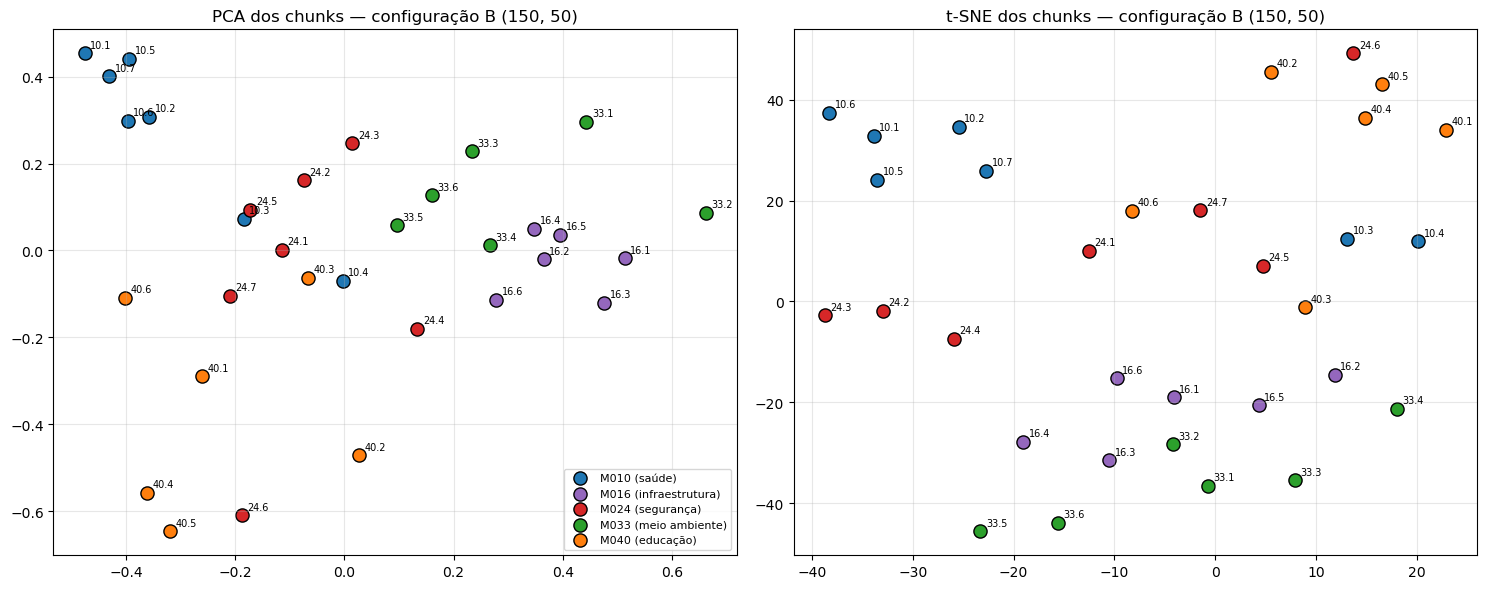

In [7]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sub = chunks[chunks.config == "B (150, 50)"].reset_index(drop=True)
E = np.vstack(sub["emb"].values)
coords = {"PCA": PCA(n_components=2, random_state=42).fit_transform(E),
          "t-SNE": TSNE(n_components=2, perplexity=8, random_state=42).fit_transform(E)}
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
cores = dict(zip(longas["id"], sns.color_palette("tab10", 5)))
for ax, (nome, C) in zip(axes, coords.items()):
    for mid, g in sub.groupby("manifestacao"):
        ax.scatter(C[g.index, 0], C[g.index, 1], s=90, color=cores[mid], edgecolor="black",
                   label=f"{mid} ({g.categoria.iloc[0]})")
        for i in g.index:
            ax.annotate(f"{mid[-2:]}.{sub.ordem[i]}", (C[i, 0], C[i, 1]), fontsize=7, xytext=(4, 4),
                        textcoords="offset points")
    ax.set_title(f"{nome} dos chunks — configuração B (150, 50)"); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [8]:
# Quantitativo: similaridade média entre chunks da MESMA manifestação vs de manifestações DIFERENTES
for cfg in CONFIGS:
    g = chunks[chunks.config == cfg]
    E = np.vstack(g["emb"].values); Sm = E @ E.T
    mesma = g["manifestacao"].values[:, None] == g["manifestacao"].values[None, :]
    off = ~np.eye(len(g), dtype=bool)
    print(f"{cfg}: mesma manifestação = {Sm[mesma & off].mean():.3f} | diferentes = {Sm[~mesma].mean():.3f}")

A (150, 0): mesma manifestação = 0.240 | diferentes = 0.113
B (150, 50): mesma manifestação = 0.249 | diferentes = 0.114
C (300, 60): mesma manifestação = 0.413 | diferentes = 0.194


## 6) Respostas às perguntas da Entrega 3

**Como o overlap influencia a coesão semântica entre chunks consecutivos?**
O overlap aumentou a coesão média de 0,225 (A, sem overlap) para 0,260 (B, overlap 50) com o mesmo tamanho de chunk. O maior ganho foi em M016 (0,237 → 0,316) e M024 (0,130 → 0,220), justamente onde uma frase longa foi cortada no meio: em A, o chunk 2 da M016 ficou só com "proteção lateral."; em B ele virou "o riacho que está com várias tábuas podres e sem proteção lateral.", que carrega o sujeito da frase. Nas manifestações em que cada frase coube inteira num chunk (M010, M033, M040), A e B deram exatamente o mesmo resultado. Isso mostra como o `RecursiveCharacterTextSplitter` funciona: o overlap só repete pedaços **menores que chunk_overlap**, então, quando a quebra cai numa fronteira de frase de ~130 caracteres, não sobra nada para sobrepor. O overlap protege as fronteiras "ruins", no meio da frase, e não muda as boas.

**Qual configuração preserva melhor o sentido das denúncias?**
Depende do que se quer preservar:
- **C (300, 60)** preserva melhor a **denúncia como um todo**. Cada chunk tem cosseno médio de 0,726 com o texto original (contra 0,525 em A e 0,537 em B), a coesão entre chunks vizinhos é a maior (0,441), e cada chunk junta problema e pedido (ex.: M016 → "a moto caiu da ponte… pedimos ponte de concreto"). Com ~215 caracteres, também gera menos da metade dos chunks (14 contra 32).
- **B (150, 50)** é melhor para **achar um detalhe específico**. Nas consultas sobre um fato no meio da denúncia, os chunks pequenos têm scores mais altos ("peixes morrendo…": 0,86 em B × 0,74 em C × 0,42 no texto inteiro; "moto caiu da ponte": 0,78 × 0,66 × 0,60). Os três chunkings acertaram a manifestação certa nas 5 consultas.
- **A (150, 0)** é o pior: cria fragmentos sem sentido próprio ("proteção lateral.", 17 caracteres).

**Escolha:** para a ouvidoria, **C (300, 60)**, porque o objetivo é classificar e agrupar denúncias, e cada chunk precisa dizer "qual é o problema e onde". Se a prioridade fosse busca por detalhes (RAG sobre as manifestações), a B seria preferível. Em ambos os casos, o chunking resolve o problema original: sem chunking, a consulta "peixes morrendo e pescadores sem sustento" tem score 0,42 contra a própria M033, porque o detalhe se dilui no vetor do texto inteiro.

**Os chunks de uma mesma manifestação ficam próximos no espaço 2D?**
Em grande parte, sim. Numericamente, a similaridade média entre chunks da mesma manifestação é cerca de 2× maior que entre manifestações diferentes em todas as configurações (C: 0,413 × 0,194; B: 0,249 × 0,114). Nos gráficos (configuração B):
- **M010 (insulina)** forma o grupo mais compacto nas duas projeções. Só os chunks que narram as idas à farmácia, sem citar remédio ou doença, se afastam.
- **M016 (ponte) e M033 (rio/entulho)** ficam na mesma região e, no t-SNE, se misturam. As duas falam de rio, ponte, cheia e comunidade, e é o mesmo par que apareceu como falso positivo na Entrega 2.
- **M024 (drogas na praça ao lado da escola)** é a mais espalhada e encosta na **M040 (acessibilidade na escola)**: as duas falam de escola, alunos e pais.

Ou seja, os chunks se agrupam pelo **assunto de cada trecho**, não pela manifestação de origem. Quando uma denúncia toca em vários temas (segurança + escola), seus chunks se distribuem entre esses temas. Isso é bom para a triagem, porque cada trecho vai para perto dos problemas parecidos, mas mostra que é preciso guardar o `id` da manifestação como metadado de cada chunk para reconstruir a denúncia original.